In [ ]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import nltk
import spacy

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.sparse import hstack
import matplotlib.pyplot as plt

In [ ]:
#Natural Language Toolkit
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
real = pd.read_csv("/content/True.csv")
fake = pd.read_csv("/content/Fake.csv")

print(real.shape)
print(fake.shape)

(21417, 4)
(23481, 4)


In [ ]:
#Selecting balanced dataset
real = real.sample(1000, random_state=42)
fake = fake.sample(1000, random_state=42)
real["label"] = 1
fake["label"] = 0
df = pd.concat([real, fake]).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Europe rights watchdog says Turkey's emergency...,BRUSSELS (Reuters) - A leading European rights...,worldnews,"October 6, 2017",1
1,Exclusive: Trump targets illegal immigrants wh...,"(Reuters) - In September 2014, Gilberto Velasq...",politicsNews,"June 9, 2017",1
2,"At G20 summit, Trump pledges $639 million in a...",HAMBURG (Reuters) - U.S. President Donald Trum...,politicsNews,"July 8, 2017",1
3,Ex-Christie associates lose bid for new trial ...,NEW YORK (Reuters) - A federal judge rejected ...,politicsNews,"March 2, 2017",1
4,Young blacks more open to Bernie Sanders' Whit...,"ORANGEBURG, S.C. (Reuters) - If Democratic hop...",politicsNews,"February 12, 2016",1


Morphological Preprocessing

In [ ]:
#morphological processing
df["sentences"] = df["text"].apply(sent_tokenize)
df["tokens"] = df["text"].apply(word_tokenize)

In [ ]:
#Stopword Strategy (Keep Pronouns)
stop_words = set(stopwords.words('english'))
pronouns = {"i","we","they","he","she","you","us"}
filtered_stopwords = stop_words - pronouns

In [ ]:
#Lemmatization
lemmatizer = WordNetLemmatizer()

def clean_tokens(tokens):
    return [lemmatizer.lemmatize(word.lower())
            for word in tokens
            if word.lower() not in filtered_stopwords]

df["clean_tokens"] = df["tokens"].apply(clean_tokens)

POS Tagging

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
df["pos_tags"] = df["clean_tokens"].apply(pos_tag)

In [ ]:
#superlative ratio
def superlative_ratio(pos_tags):
    count = sum(1 for word, tag in pos_tags if tag in ["JJS","RBS"])
    return count / len(pos_tags) if len(pos_tags)>0 else 0
df["superlative_ratio"] = df["pos_tags"].apply(superlative_ratio)

In [ ]:
#proper noun ratio
def proper_noun_ratio(pos_tags):
    count = sum(1 for word, tag in pos_tags if tag == "NNP")
    return count / len(pos_tags) if len(pos_tags)>0 else 0
df["proper_noun_ratio"] = df["pos_tags"].apply(proper_noun_ratio)

In [ ]:
#personal pronoun ratio
def pronoun_ratio(pos_tags):
    first = sum(1 for word, tag in pos_tags if word.lower() in ["i","we"])
    third = sum(1 for word, tag in pos_tags if word.lower() in ["he","she","they"])
    return first / (third+1)

df["pronoun_ratio"] = df["pos_tags"].apply(pronoun_ratio)

Sentence Length Feature

In [ ]:
df["avg_sentence_length"] = df["sentences"].apply(
    lambda sents: (
        sum(len(word_tokenize(s)) for s in sents) / len(sents)
        if len(sents) > 0 else 0
    )
)

TF-IDF (term frequency - inverse document frequency)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df["text"])

Combine features

In [ ]:
ling_features = df[[
    "superlative_ratio",
    "proper_noun_ratio",
    "pronoun_ratio",
    "avg_sentence_length"
]].values

X_combined = hstack([X_tfidf, ling_features])

## **Train Model**

Train with linguistics

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df["label"], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("TF_IDF with linguistics Accuracy:", model.score(X_test, y_test))

TF_IDF with linguistics Accuracy: 0.955


Train without linguistics

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_tfidf, df["label"], test_size=0.2, random_state=42)

model2 = LogisticRegression(max_iter=200)
model2.fit(X_train2, y_train2)

print("TF-IDF Only Accuracy:", model2.score(X_test2, y_test2))

TF-IDF Only Accuracy: 0.96


In [ ]:
from sklearn.metrics import classification_report

#with linguistics
y_pred_combined = model.predict(X_test)
print("===== TF-IDF + LINGUISTIC FEATURES MODEL ===telek")
print(classification_report(y_test, y_pred_combined))

===== TF-IDF + LINGUISTIC FEATURES MODEL ===telek
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       201
           1       0.96      0.94      0.95       199

    accuracy                           0.95       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.95      0.95       400



In [ ]:
#withouth linguistics
y_pred2 = model2.predict(X_test2)
from sklearn.metrics import classification_report
print("===== TF-IDF ONLY MODEL =====")
print(classification_report(y_test2, y_pred2))

===== TF-IDF ONLY MODEL =====
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       201
           1       0.97      0.95      0.96       199

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



**Confusion matrix**

Confusion Matrix (Combined Model):


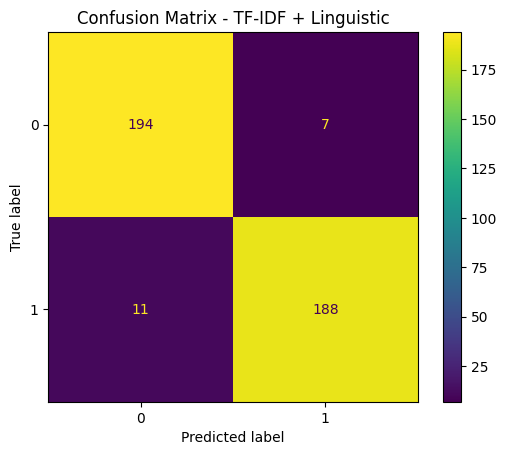

In [ ]:
cm_combined = confusion_matrix(y_test, y_pred_combined)
print("Confusion Matrix (Combined Model):")
ConfusionMatrixDisplay(cm_combined).plot()
plt.title("Confusion Matrix - TF-IDF + Linguistic")
plt.show()

Confusion Matrix (TF-IDF Only):


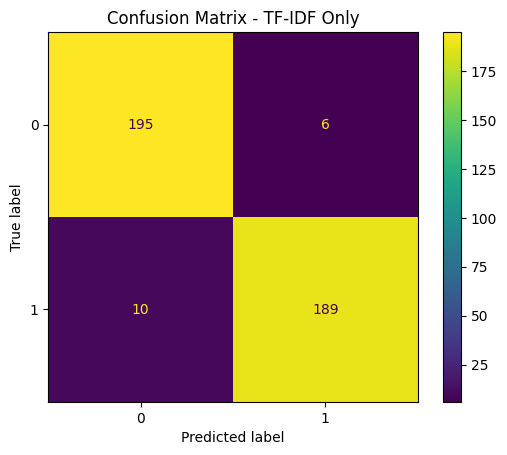

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm2 = confusion_matrix(y_test2, y_pred2)

print("Confusion Matrix (TF-IDF Only):")
ConfusionMatrixDisplay(cm2).plot()
plt.title("Confusion Matrix - TF-IDF Only")
plt.show()

**COMPARISON**

In [ ]:
acc_tfidf = model2.score(X_test2, y_test2)
acc_combined = model.score(X_test, y_test)

print("TF-IDF Only Accuracy:", acc_tfidf)
print("Combined Model Accuracy:", acc_combined)

TF-IDF Only Accuracy: 0.96
Combined Model Accuracy: 0.955


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = {
    "Model": ["TF-IDF Only", "TF-IDF + Linguistic"],
    "Accuracy": [
        acc_tfidf,
        acc_combined
    ],
    "Precision": [
        precision_score(y_test2, y_pred2),
        precision_score(y_test, y_pred_combined)
    ],
    "Recall": [
        recall_score(y_test2, y_pred2),
        recall_score(y_test, y_pred_combined)
    ],
    "F1 Score": [
        f1_score(y_test2, y_pred2),
        f1_score(y_test, y_pred_combined)
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF Only,0.960,0.969231,0.949749,0.959391
1,TF-IDF + Linguistic,0.955,0.964103,0.944724,0.954315


# Visualization of TF-IDF features

In [ ]:
# Top TF-IDF Words Plot

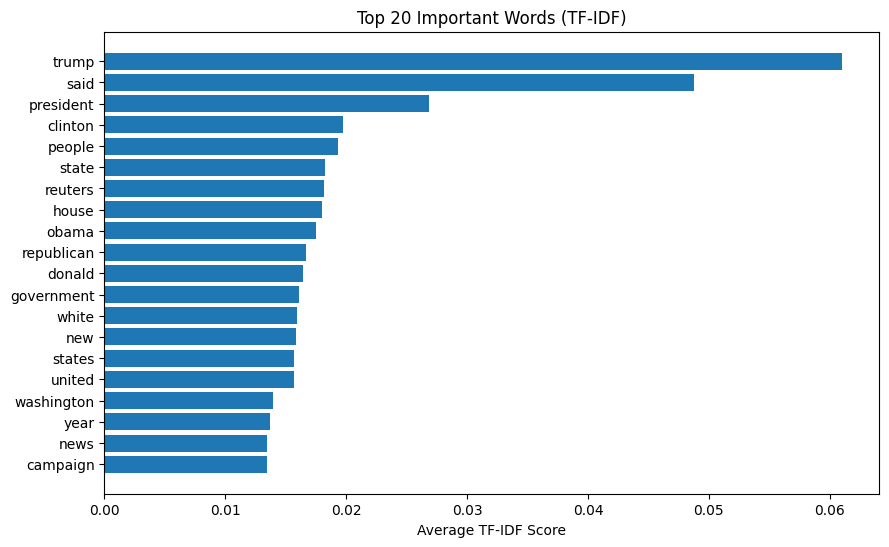

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Get average TF-IDF score for each word
avg_tfidf = X_tfidf.mean(axis=0).A1

# Get top 20 words
top_n = 20
top_indices = np.argsort(avg_tfidf)[-top_n:]

top_words = feature_names[top_indices]
top_scores = avg_tfidf[top_indices]

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_words, top_scores)
plt.xlabel("Average TF-IDF Score")
plt.title("Top 20 Important Words (TF-IDF)")
plt.show()

PCA Projection

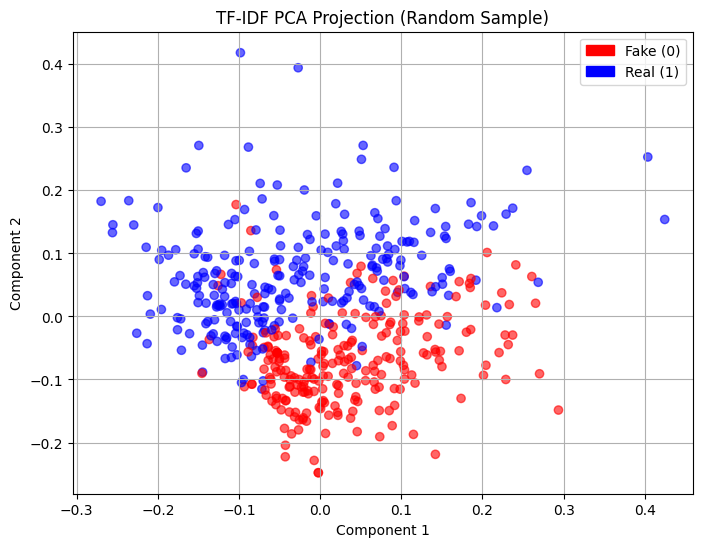

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Random sampling
sample_size = 500
sample_indices = np.random.choice(len(df), sample_size, replace=False)

X_sample = X_tfidf[sample_indices].toarray()
y_sample = df["label"].iloc[sample_indices].values

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Colors
colors = ['red' if label == 0 else 'blue' for label in y_sample]

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.6)

# Legend
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color='red', label='Fake (0)'),
    mpatches.Patch(color='blue', label='Real (1)')
])

plt.title("TF-IDF PCA Projection (Random Sample)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

# Syntax Analysis (Tree Depth)

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
def tree_depth(sentence):
    doc = nlp(sentence)
    depths = []

    for token in doc:
        depth = 0
        head = token
        while head.head != head:
            head = head.head
            depth += 1
        depths.append(depth)

    return max(depths) if depths else 0

In [ ]:
#Sample 50 sentences per classes
real_sentences = (
    df[df.label==1]["sentences"]
    .explode()
    .dropna()
    .sample(50, random_state=42)
)

fake_sentences = (
    df[df.label==0]["sentences"]
    .explode()
    .dropna()
    .sample(50, random_state=42)
)

In [ ]:
#comppute average tree depth
real_depths = [tree_depth(sent) for sent in real_sentences]
fake_depths = [tree_depth(sent) for sent in fake_sentences]

print("Average Tree Depth - Real:", sum(real_depths)/len(real_depths))
print("Average Tree Depth - Fake:", sum(fake_depths)/len(fake_depths))

Average Tree Depth - Real: 6.76
Average Tree Depth - Fake: 5.9


# LINGUISTIC PROFILE TABLE

In [ ]:
#compute adjective count
def adjective_count(pos_tags):
    return sum(1 for word, tag in pos_tags if tag in ["JJ","JJR","JJS"])

df["adj_count"] = df["pos_tags"].apply(adjective_count)

In [ ]:
#compute class wise mean
profile = df.groupby("label")[[
    "adj_count",
    "avg_sentence_length"
]].mean()

profile

,adj_count,avg_sentence_length
label,,
0,48.832,33.627084
1,47.336,31.248266


In [ ]:
profile.index = ["Fake", "Real"]
profile

,adj_count,avg_sentence_length
Fake,48.832,33.627084
Real,47.336,31.248266


## ERROR ANALYSIS(Identify Misclassified Real Articles)

In [ ]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_combined,
    df["label"],
    df.index,                 #  THIS keeps original indices
    test_size=0.2,
    random_state=42
)

In [ ]:
y_pred_combined = model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    "text": df.loc[idx_test, "text"].values,
    "true": y_test.values,
    "pred": y_pred_combined
})

In [ ]:
misclassified_real = results[
    (results["true"] == 1) &
    (results["pred"] == 0)
]

misclassified_real.head(1)

,text,true,pred
10,SOFIA (Reuters) - Couples lining up to face ea...,1,0


In [ ]:
print(misclassified_real.iloc[0]["text"])

SOFIA (Reuters) - Couples lining up to face each other are given 30 seconds to chat before moving on - in a version of speed dating that, rather than sparking romance, aims to promote understanding and integration for new immigrants. At a social center in the Bulgarian capital Sofia, the locals stand on one side, the immigrants - many refugees from Syria, Afghanistan and other war-torn countries - face them.  The quick-fire conversations - in which participants have just seconds to share their dreams and stories of love, pain and family - are aimed at starting a dialogue between two communities that in normal daily life rarely speak to each other on an equal footing.  It s so good to have an event like this, especially for refugees,  said Rodi Naamo, a 26-year-old Syrian Kurd who arrived in Bulgaria in 2015, when hundreds of thousands of migrants passed through the Balkans en route to Germany and northern Europe.  Bulgarians also appreciated the speedy encounters, as well as the Middle